In [ ]:
import os
import sys
from google.colab import drive

drive.mount('/content/drive')

if os.path.exists('/content/Motor_Fault_Detection'):
    os.system('git -C /content/Motor_Fault_Detection pull')
    print("Repo updated")
else:
    os.system('git clone https://github.com/dante-jpg2003/Motor_Fault_Detection.git /content/Motor_Fault_Detection')
    print("Repo cloned")

print("Scripts:", os.listdir('/content/Motor_Fault_Detection/scripts'))
print("Drive mounted:", os.path.exists('/content/drive/MyDrive'))

Mounted at /content/drive
Repo cloned
Scripts: ['dataset.py', 'model.py', 'train.py', 'evaluate.py', 'Libraries.py']
Drive mounted: True


In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'scipy', 'scikit-learn', '-q'])
print("Dependencies installed")

Dependencies installed


In [ ]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU — go to Runtime → Change runtime type → T4 GPU")

GPU available: True
Device: Tesla T4


In [ ]:
# Cell 2b — Monitor memory
import psutil
import gc

def print_memory():
    ram = psutil.virtual_memory()
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB "
          f"({ram.percent}% used)")
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / 1e9
        gpu_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {gpu_mem:.1f}/{gpu_total:.1f} GB used")

print("Before loading:")
print_memory()

Before loading:
RAM: 1.1/13.6 GB (10.8% used)
GPU: 0.0/15.6 GB used


In [ ]:
os.environ['MOTOR_DATA_DIR'] = (
    '/content/drive/MyDrive/Motor_Fault_Detection/data/raw'
)
os.environ['MOTOR_RESULTS_DIR'] = (
    '/content/drive/MyDrive/Motor_Fault_Detection/results'
)
sys.path.append('/content/Motor_Fault_Detection/scripts')
print("Paths configured")
print("Data dir:", os.environ['MOTOR_DATA_DIR'])
print("Results dir:", os.environ['MOTOR_RESULTS_DIR'])

Paths configured
Data dir: /content/drive/MyDrive/Motor_Fault_Detection/data/raw
Results dir: /content/drive/MyDrive/Motor_Fault_Detection/results


In [ ]:
from train import train

CONFIG = {
    'window_size'  : 800,
    'stride'       : 800,
    'batch_size'   : 32,
    'epochs'       : 10,
    'learning_rate': 1e-3,
    'weight_decay' : 1e-4,
    'train_ratio'  : 0.8,
    'random_seed'  : 42,
    'num_classes'  : 6,
    'num_channels' : 9,
}
print_memory()
model, history = train(CONFIG)
print_memory()

RAM: 1.1/13.6 GB (10.9% used)
GPU: 0.0/15.6 GB used
Using device: cuda
Config: {
  "window_size": 800,
  "stride": 800,
  "batch_size": 32,
  "epochs": 10,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "train_ratio": 0.8,
  "random_seed": 42,
  "num_classes": 6,
  "num_channels": 9
}

LOADING DATA
Loaded NF: (329, 10000, 9), label=5
Loaded OP: (703, 10000, 9), label=1
Loaded 2PSC: (753, 10000, 9), label=3
Loaded 1PSC: (767, 10000, 9), label=4
Loaded REVD: (518, 10000, 9), label=2
Loaded VREC: (322, 10000, 9), label=0

Total loaded: (3392, 10000, 9)
Memory usage: 1.22 GB

SPLITTING DATA
Train: 2713 experiments
Test:  679 experiments

Class distribution:
Class       Train     Test
0             258       64
1             562      141
2             414      104
3             602      151
4             614      153
5             263       66

NORMALISING
Normalisation statistics (per channel):
Channel          Mean        Std
Ch 0           0.1119    53.1883
Ch 1          -0.1527  

In [ ]:
# Create results directories on Drive if they don't exist
results_dir = os.environ['MOTOR_RESULTS_DIR']
os.makedirs(os.path.join(results_dir, 'figures'), exist_ok=True)
os.makedirs(os.path.join(results_dir, 'logs'), exist_ok=True)
print("Results directories ready")

Results directories ready


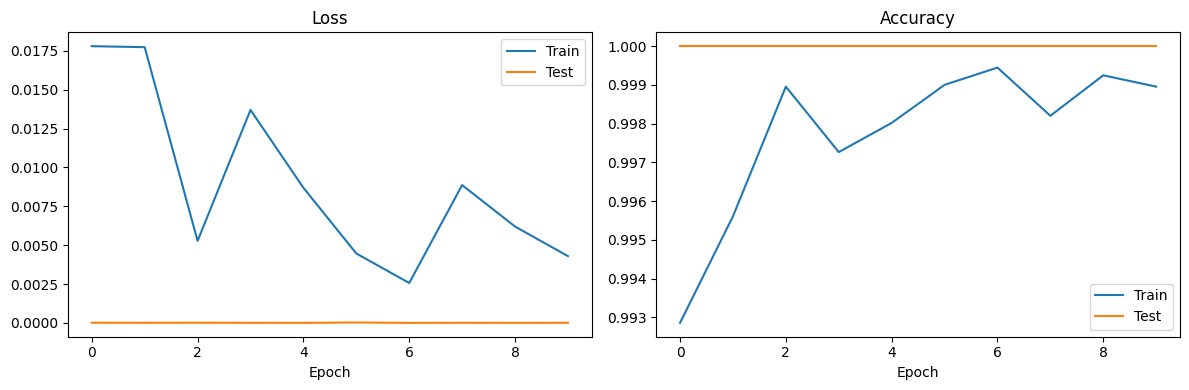

In [ ]:
import json
import matplotlib.pyplot as plt

with open(os.path.join(os.environ['MOTOR_RESULTS_DIR'],
                        'training_history.json')) as f:
    history = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['test_loss'],  label='Test')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['test_acc'],  label='Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(os.environ['MOTOR_RESULTS_DIR'],
                          'figures/training_curves.png'), dpi=150)
plt.show()

Using device: cuda

LOADING MODEL AND DATA
Loaded model from epoch 1 with test acc 1.0000
Train: 2713 experiments
Test:  679 experiments

Class distribution:
Class       Train     Test
0             258       64
1             562      141
2             414      104
3             602      151
4             614      153
5             263       66
Created 8,148 windows (window=800, stride=800)

Running inference on test set...
Total windows evaluated: 8,148

OVERALL METRICS
Overall Accuracy: 1.0000 (100.00%)

PER-CLASS METRICS

Class     Precision     Recall         F1    Support
----------------------------------------------------
VREC         1.0000     1.0000     1.0000        768
OP           1.0000     1.0000     1.0000       1692
REVD         1.0000     1.0000     1.0000       1248
2PSC         1.0000     1.0000     1.0000       1812
1PSC         1.0000     1.0000     1.0000       1836
NF           1.0000     1.0000     1.0000        792
---------------------------------------------

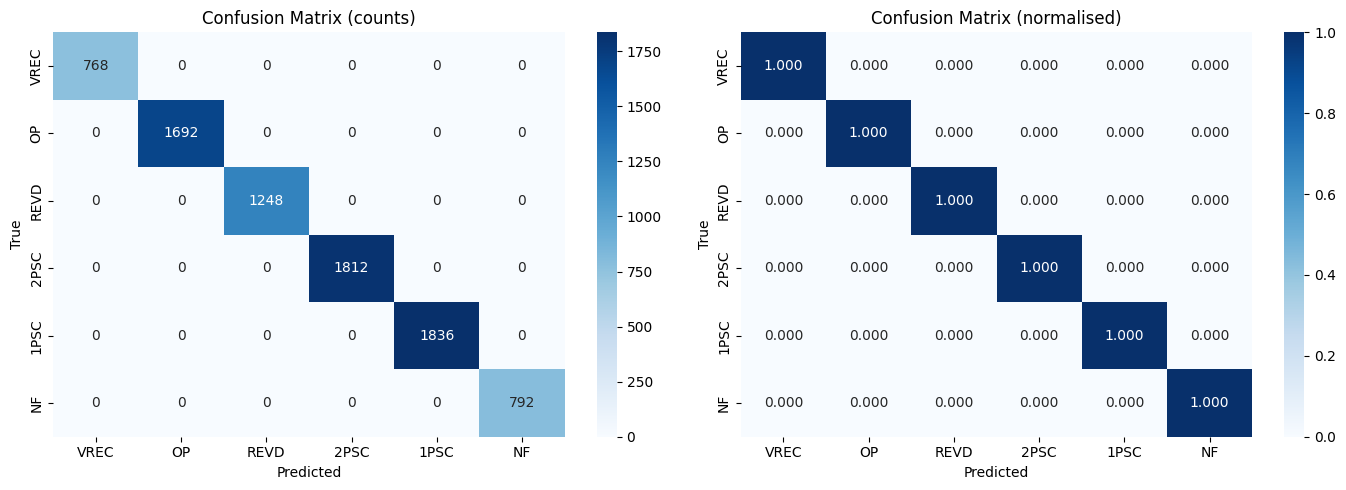

Saved confusion matrix to /content/drive/MyDrive/Motor_Fault_Detection/results/figures/confusion_matrix.png


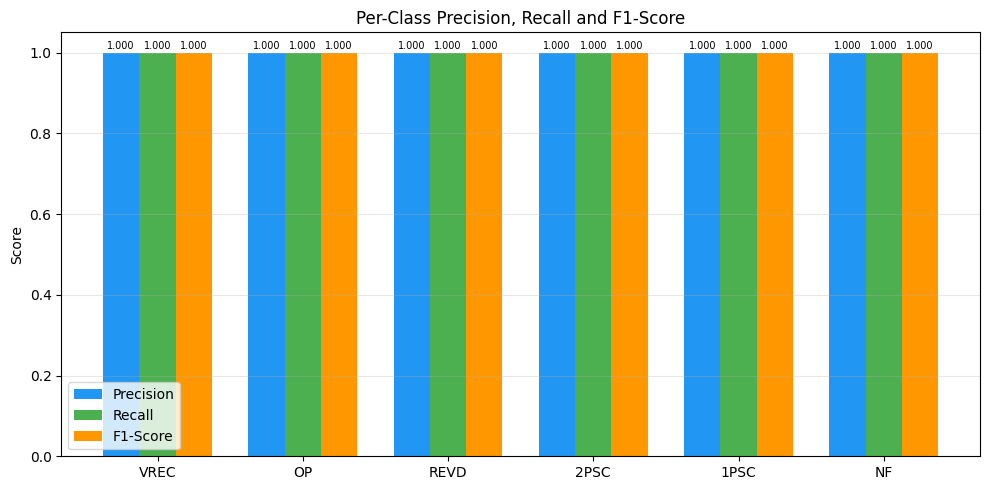

Saved per-class metrics to /content/drive/MyDrive/Motor_Fault_Detection/results/figures/per_class_metrics.png


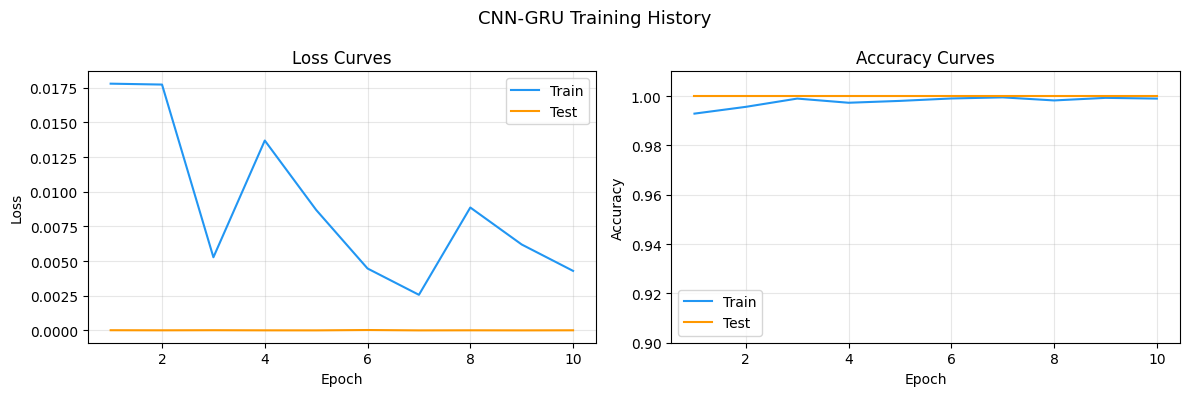

Saved training curves to /content/drive/MyDrive/Motor_Fault_Detection/results/figures/training_curves.png


In [ ]:
# Cell 7 — Run evaluation
os.environ['MOTOR_RESULTS_DIR'] = (
    '/content/drive/MyDrive/Motor_Fault_Detection/results'
)

from evaluate import evaluate

results = evaluate(
    checkpoint_path = os.path.join(
        os.environ['MOTOR_RESULTS_DIR'], 'best_model.pt'
    ),
    window_size = 800,
    stride      = 800
)

In [ ]:
# Cell 8 — Window size experiments (clean version)
import os
import sys
import json
import importlib
import matplotlib.pyplot as plt

# Make sure scripts path is added
SCRIPTS_PATH = '/content/Motor_Fault_Detection/scripts'
if SCRIPTS_PATH not in sys.path:
    sys.path.insert(0, SCRIPTS_PATH)

window_sizes       = [100, 200, 400, 600, 800]
experiment_results = []

for w in window_sizes:
    print(f"\n{'='*55}")
    print(f"TRAINING WITH WINDOW SIZE = {w}")
    print(f"{'='*55}")

    # Set directories
    window_results_dir = (
        f'/content/drive/MyDrive/Motor_Fault_Detection/results/window_{w}'
    )
    window_figures_dir = os.path.join(window_results_dir, 'figures')

    # Create directories explicitly
    os.makedirs(window_results_dir, exist_ok=True)
    os.makedirs(window_figures_dir, exist_ok=True)
    print(f"✓ Directories created")

    # Update environment variable
    os.environ['MOTOR_DATA_DIR']    = (
        '/content/drive/MyDrive/Motor_Fault_Detection/data/raw'
    )
    os.environ['MOTOR_RESULTS_DIR'] = window_results_dir

    # Force reload modules to pick up new env vars
    import train    as train_module
    import evaluate as evaluate_module
    importlib.reload(train_module)
    importlib.reload(evaluate_module)

    CONFIG = {
        'window_size'  : w,
        'stride'       : w,
        'batch_size'   : 64,
        'epochs'       : 10,
        'learning_rate': 1e-3,
        'weight_decay' : 1e-4,
        'train_ratio'  : 0.8,
        'random_seed'  : 42,
        'num_classes'  : 6,
        'num_channels' : 9,
    }

    # Train
    model, history = train_module.train(CONFIG)

    # Verify checkpoint
    checkpoint_path = os.path.join(window_results_dir, 'best_model.pt')
    if os.path.exists(checkpoint_path):
        print(f"✓ Checkpoint saved")
    else:
        print(f"✗ Checkpoint NOT found at {checkpoint_path}")
        continue

    # Evaluate
    results = evaluate_module.evaluate(
        checkpoint_path = checkpoint_path,
        window_size     = w,
        stride          = w
    )

    # Verify figures
    saved_figures = os.listdir(window_figures_dir)
    print(f"✓ Figures saved: {saved_figures}")

    experiment_results.append({
        'window_size'    : w,
        'accuracy'       : results['overall_accuracy'],
        'precision'      : results['macro_avg']['precision'],
        'recall'         : results['macro_avg']['recall'],
        'f1'             : results['macro_avg']['f1'],
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc' : history['test_acc'][-1]
    })

    print(f"Window {w} complete — Accuracy: {results['overall_accuracy']:.4f}")

# Save experiment results summary
summary_path = (
    '/content/drive/MyDrive/Motor_Fault_Detection/results/window_comparison.json'
)
with open(summary_path, 'w') as f:
    json.dump(experiment_results, f, indent=2)
print(f"\n✓ Summary saved to {summary_path}")

# Print summary table
print("\n" + "="*65)
print("WINDOW SIZE EXPERIMENT SUMMARY")
print("="*65)
print(f"{'Window':<10} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("-"*55)
for r in experiment_results:
    print(f"{r['window_size']:<10} {r['accuracy']:>10.4f} "
          f"{r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1']:>10.4f}")

In [ ]:
# Cell 9 — Plot window size comparison
import matplotlib.pyplot as plt
import numpy as np
import json

windows   = [r['window_size'] for r in experiment_results]
accuracies = [r['accuracy']   for r in experiment_results]
f1_scores  = [r['f1']         for r in experiment_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy vs window size
axes[0].plot(windows, accuracies, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Window Size (time points)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Window Size')
axes[0].set_xticks(windows)
axes[0].set_ylim(0.9, 1.01)
axes[0].grid(alpha=0.3)
for x, y in zip(windows, accuracies):
    axes[0].annotate(f'{y:.4f}', (x, y),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center')

# F1 vs window size
axes[1].plot(windows, f1_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Window Size (time points)')
axes[1].set_ylabel('Macro F1-Score')
axes[1].set_title('F1-Score vs Window Size')
axes[1].set_xticks(windows)
axes[1].set_ylim(0.9, 1.01)
axes[1].grid(alpha=0.3)
for x, y in zip(windows, f1_scores):
    axes[1].annotate(f'{y:.4f}', (x, y),
                     textcoords="offset points",
                     xytext=(0, 10), ha='center')

plt.suptitle('CNN-GRU Performance Across Window Sizes', fontsize=13)
plt.tight_layout()

save_path = '/content/drive/MyDrive/Motor_Fault_Detection/results/figures/window_comparison.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Window comparison plot saved")

times = []
for w in window_sizes:
    history_path = (
        f'/content/drive/MyDrive/Motor_Fault_Detection/'
        f'results/window_{w}/training_history.json'
    )
    with open(history_path) as f:
        history = json.load(f)

    # Count windows per experiment for this window size
    windows_per_exp = 10000 // w
    total_windows   = windows_per_exp * 3392
    times.append(total_windows)

# Plot windows per experiment vs window size
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(w) for w in window_sizes], times, color='#2196F3')
ax.set_xlabel('Window Size')
ax.set_ylabel('Total Training Windows')
ax.set_title('Dataset Size vs Window Size\n(all achieve 100% accuracy)')

for bar, count in zip(ax.patches, times):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{count:,}',
        ha='center', fontsize=9
    )

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Motor_Fault_Detection/'
    'results/figures/window_dataset_size.png',
    dpi=150
)
plt.show()

print("\nKey insight: window=100 achieves same accuracy with "
      f"{times[-1]//times[0]}x more training samples than window=800")
print("Recommendation: window=800 is most efficient for this dataset")